In [1]:
import pandas as pd

In [2]:
%pwd
%cd /home/jovyan/work/results/Cell/
%pwd

/home/jovyan/work/results/Cell


'/home/jovyan/work/results/Cell'

In [3]:
# import the PCC data
pcc_4S = pd.read_csv("pcc_4S.csv", index_col=0)
pcc_I = pd.read_csv("pcc_I.csv", index_col=0)
pcc_III = pd.read_csv("pcc_III.csv", index_col=0)
pcc_IV = pd.read_csv("pcc_IV.csv", index_col=0)
# pcc_NA = pd.read_csv("pcc_NA.csv", index_col=0)
pcc_4S

,TSPAN6,DPM1,SCYL3,C1orf112,FGR,FUCA2,GCLC,NFYA,STPG1,NIPAL3,...,SEPSECS-AS1,LINC01144,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,1.000000,0.101876,-0.105444,0.294110,0.285490,0.043094,0.273760,0.154205,0.535308,0.574785,...,-0.214314,-0.225862,0.491546,0.099288,0.247549,-0.177206,0.227948,-0.268659,0.047149,-0.721479
DPM1,0.101876,1.000000,0.040753,0.366840,0.112091,-0.203120,0.277659,0.230100,0.012097,-0.223822,...,-0.017635,-0.288416,0.410572,0.095112,0.348526,0.411757,-0.319794,-0.130364,0.225836,-0.290486
SCYL3,-0.105444,0.040753,1.000000,0.378629,-0.077102,0.299282,0.164965,0.239981,-0.208912,0.051952,...,0.622151,0.586767,0.021289,0.030100,0.392734,0.130584,0.244455,0.441587,0.019297,0.122590
C1orf112,0.294110,0.366840,0.378629,1.000000,0.090887,0.202204,0.276277,0.408218,-0.028448,0.043607,...,0.243748,0.095764,0.304032,0.119730,0.447024,-0.121551,0.210028,0.290213,-0.177887,-0.509990
FGR,0.285490,0.112091,-0.077102,0.090887,1.000000,-0.117195,0.082018,-0.002028,0.309746,0.378912,...,0.061240,0.080967,0.612712,0.711971,0.284195,0.071398,0.207367,-0.222435,0.442745,-0.239477
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,-0.177206,0.411757,0.130584,-0.121551,0.071398,-0.431935,-0.214156,-0.163260,0.100622,-0.076020,...,0.350383,0.075384,0.190224,0.019012,0.208961,1.000000,-0.613841,-0.308633,0.599359,0.277204
CYB561D2,0.227948,-0.319794,0.244455,0.210028,0.207367,0.558621,0.306613,0.189181,0.124066,0.351359,...,0.070697,0.309529,0.159834,0.172155,0.138332,-0.613841,1.000000,0.342137,-0.458748,-0.186283
CCDC7,-0.268659,-0.130364,0.441587,0.290213,-0.222435,0.542627,0.210271,0.254534,-0.347429,-0.078083,...,0.285602,0.507611,-0.117943,-0.003734,0.117266,-0.308633,0.342137,1.000000,-0.371967,0.101145


construct an unweighted graph of edges based on whether the PCC exceeds the theshold.

delete rows and columns with Inf entries, since those genes are deleted from the module. (already ensured the genes won't contribute to potential modules candidates by assuring only 1 connected component is >= 3 in the previous graph)

write the function that convertes PCC matrix to distance matrix

In [4]:
# take a look what values should be set as thresholds
sum = 0
for colname in pcc_4S:
    for value in pcc_4S[colname]:
        if value > 0.7:
            sum += 1
print(sum/(pcc_4S.shape[0]**2))

0.015411409166177814


In [5]:
import sys
sys.path.append('/home/jovyan/work/FUNCTIONS/')
from SWITCH import Binary_SWITCH_pcc_to_distance

In [6]:
%pwd
%cd /home/jovyan/work/parameter_tuning/Binary_SWITCH/Cell/
%pwd

/home/jovyan/work/parameter_tuning/Binary_SWIM/Cell


'/home/jovyan/work/parameter_tuning/Binary_SWIM/Cell'

IGRAPH UN-- 12939 1322561 -- 
+ attr: name (v)
graph is connected: False


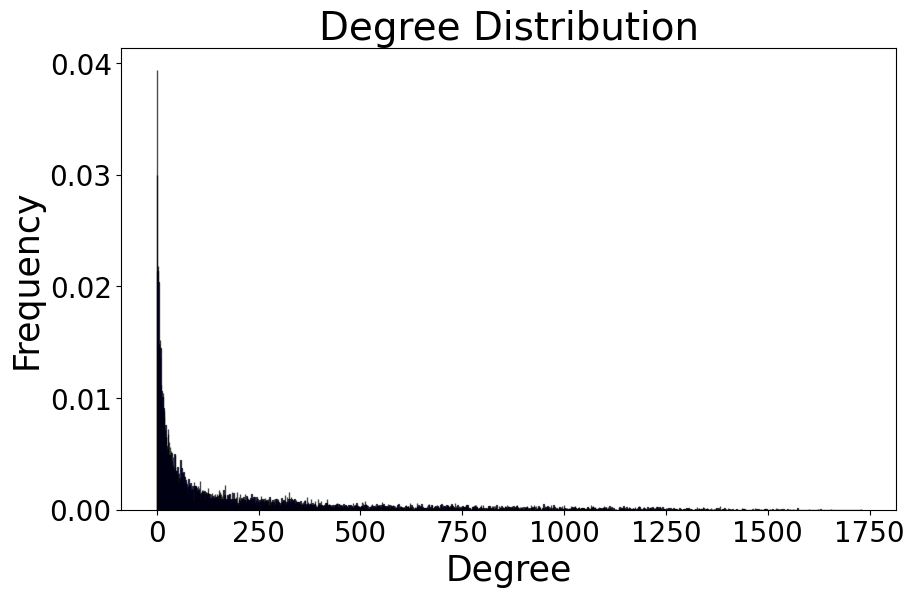

All Pairs Distances:
<class 'list'>
12939X12939


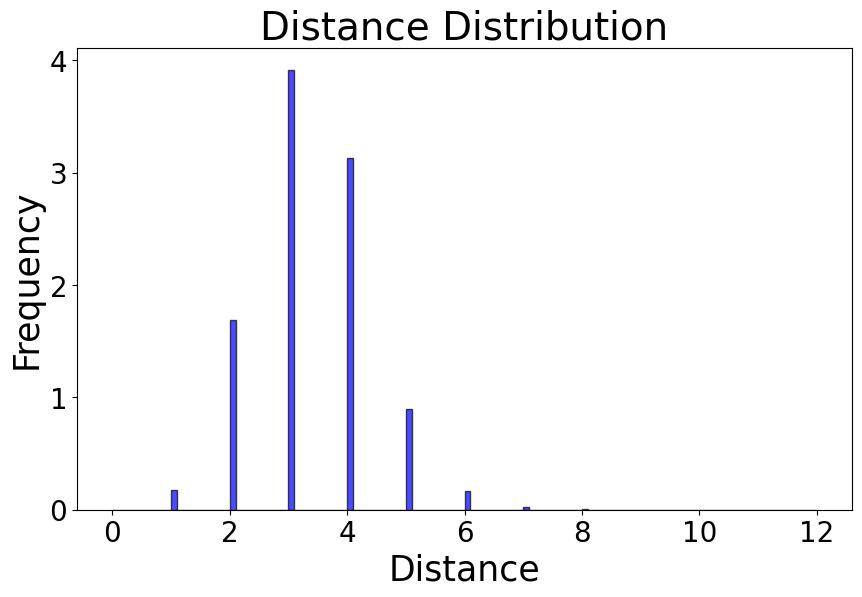

Number of vertices in largest connected component: 12390
Number of edges in largest connected component: 1322541


Symbol,TSPAN6,DPM1,SCYL3,C1orf112,FGR,FUCA2,GCLC,NFYA,STPG1,NIPAL3,...,LINC01176,SEPSECS-AS1,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,0.0,3.0,3.0,3.0,3.0,4.0,3.0,4.0,2.0,2.0,...,3.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,1.0
DPM1,3.0,0.0,3.0,3.0,4.0,4.0,3.0,3.0,4.0,3.0,...,3.0,5.0,4.0,4.0,4.0,2.0,3.0,4.0,3.0,3.0
SCYL3,3.0,3.0,0.0,3.0,4.0,3.0,4.0,3.0,3.0,4.0,...,3.0,3.0,4.0,5.0,3.0,3.0,3.0,3.0,4.0,3.0
C1orf112,3.0,3.0,3.0,0.0,4.0,3.0,3.0,3.0,4.0,3.0,...,2.0,4.0,3.0,4.0,3.0,3.0,3.0,3.0,4.0,2.0
FGR,3.0,4.0,4.0,4.0,0.0,4.0,3.0,4.0,3.0,3.0,...,3.0,5.0,2.0,1.0,3.0,4.0,3.0,4.0,3.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,3.0,2.0,3.0,3.0,4.0,3.0,3.0,3.0,4.0,3.0,...,2.0,4.0,4.0,4.0,4.0,0.0,2.0,3.0,2.0,3.0
CYB561D2,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,...,3.0,5.0,4.0,4.0,4.0,2.0,0.0,3.0,3.0,3.0
CCDC7,3.0,4.0,3.0,3.0,4.0,2.0,3.0,3.0,4.0,4.0,...,2.0,3.0,4.0,4.0,4.0,3.0,3.0,0.0,4.0,3.0


In [7]:
distance_4S = Binary_SWITCH_pcc_to_distance(pcc_matrix=pcc_4S, fig_path1="./figures/degree_distribution_4S.svg", fig_path2="./figures/distance_distribution_4S.svg", pcc_threshold=0.7)
distance_4S.to_csv("distance_4S.csv")
distance_4S

IGRAPH UN-- 12939 1215109 -- 
+ attr: name (v)
graph is connected: False


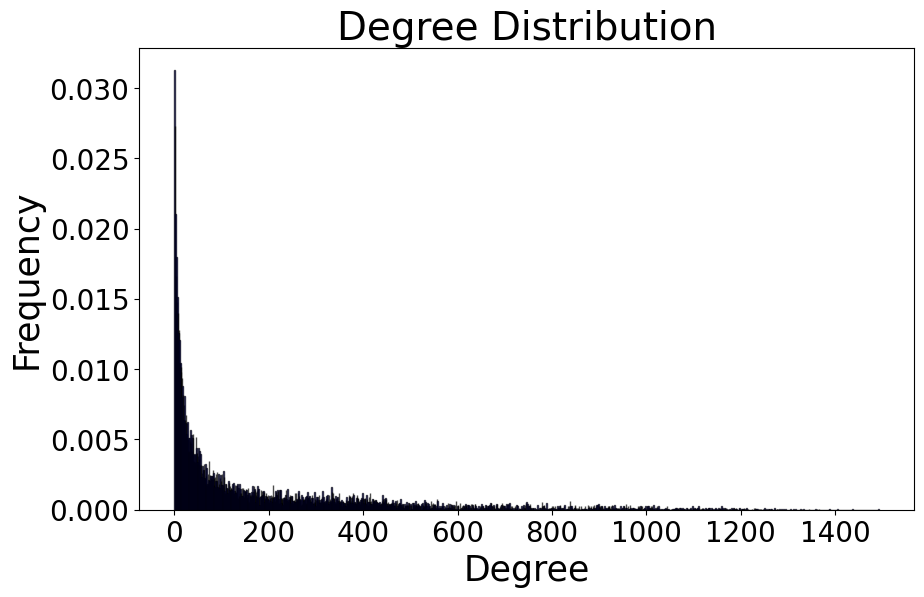

All Pairs Distances:
<class 'list'>
12939X12939


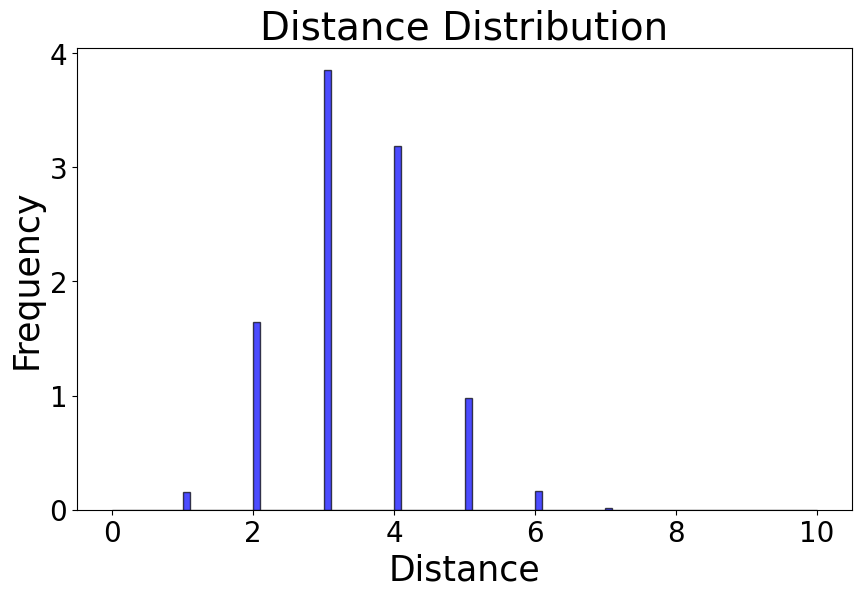

Number of vertices in largest connected component: 12515
Number of edges in largest connected component: 1215099


Symbol,TSPAN6,DPM1,SCYL3,C1orf112,FGR,FUCA2,GCLC,NFYA,STPG1,NIPAL3,...,LINC01176,LINC01144,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,0.0,3.0,4.0,4.0,4.0,4.0,3.0,4.0,3.0,4.0,...,5.0,4.0,3.0,4.0,4.0,4.0,4.0,4.0,3.0,4.0
DPM1,3.0,0.0,4.0,2.0,4.0,4.0,3.0,3.0,3.0,3.0,...,3.0,5.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0
SCYL3,4.0,4.0,0.0,3.0,4.0,3.0,3.0,3.0,4.0,4.0,...,3.0,3.0,4.0,4.0,2.0,3.0,3.0,2.0,3.0,3.0
C1orf112,4.0,2.0,3.0,0.0,4.0,3.0,3.0,2.0,4.0,2.0,...,3.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0
FGR,4.0,4.0,4.0,4.0,0.0,4.0,4.0,4.0,3.0,3.0,...,4.0,2.0,1.0,1.0,2.0,3.0,3.0,4.0,2.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,4.0,3.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,...,3.0,3.0,3.0,3.0,3.0,0.0,2.0,2.0,1.0,3.0
CYB561D2,4.0,3.0,3.0,3.0,3.0,2.0,3.0,3.0,3.0,3.0,...,4.0,4.0,3.0,4.0,4.0,2.0,0.0,2.0,2.0,3.0
CCDC7,4.0,3.0,2.0,3.0,4.0,2.0,3.0,3.0,3.0,3.0,...,3.0,4.0,3.0,4.0,3.0,2.0,2.0,0.0,2.0,3.0


In [8]:
distance_I = Binary_SWITCH_pcc_to_distance(pcc_matrix=pcc_I, fig_path1="./figures/degree_distribution_I.svg", fig_path2="./figures/distance_distribution_I.svg", pcc_threshold=0.7)
distance_I.to_csv("distance_I.csv")
distance_I

IGRAPH UN-- 12939 1856546 -- 
+ attr: name (v)
graph is connected: False


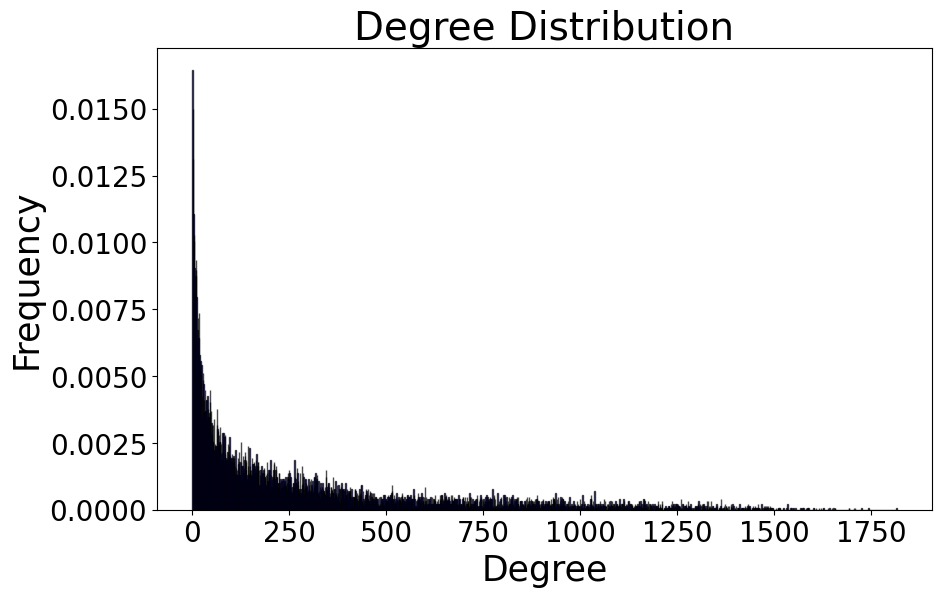

All Pairs Distances:
<class 'list'>
12939X12939


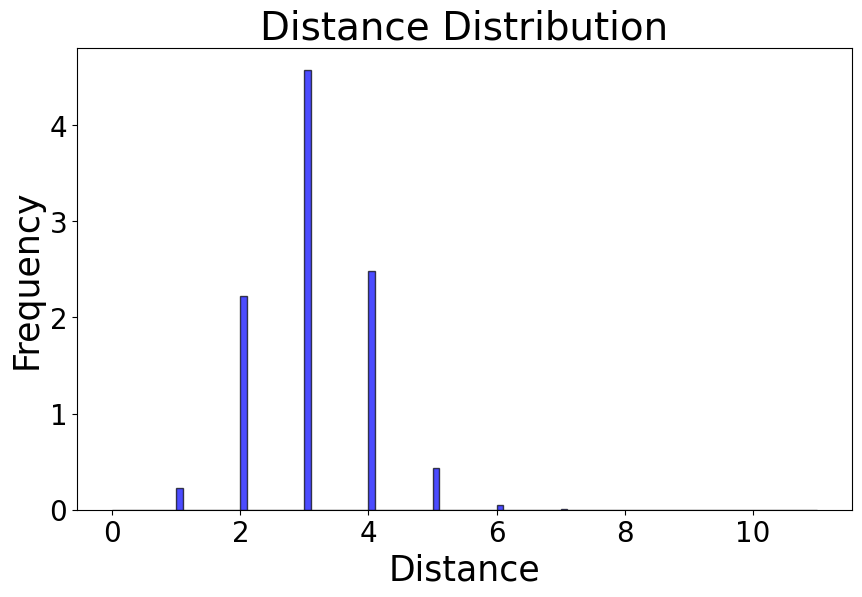

Number of vertices in largest connected component: 12707
Number of edges in largest connected component: 1856535


Symbol,TSPAN6,DPM1,SCYL3,C1orf112,FGR,GCLC,NFYA,STPG1,NIPAL3,LAS1L,...,SEPSECS-AS1,LINC01144,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,0.0,3.0,2.0,3.0,4.0,3.0,3.0,2.0,2.0,2.0,...,4.0,3.0,3.0,4.0,3.0,4.0,5.0,2.0,3.0,3.0
DPM1,3.0,0.0,3.0,3.0,4.0,4.0,3.0,4.0,3.0,4.0,...,5.0,5.0,4.0,4.0,4.0,4.0,5.0,4.0,3.0,3.0
SCYL3,2.0,3.0,0.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,3.0,2.0,3.0,3.0,2.0,3.0,5.0,2.0,2.0,3.0
C1orf112,3.0,3.0,3.0,0.0,3.0,3.0,2.0,3.0,3.0,3.0,...,3.0,4.0,3.0,4.0,3.0,4.0,4.0,3.0,3.0,3.0
FGR,4.0,4.0,3.0,3.0,0.0,4.0,3.0,3.0,4.0,3.0,...,5.0,2.0,2.0,1.0,3.0,4.0,5.0,3.0,3.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,4.0,4.0,3.0,4.0,4.0,5.0,4.0,4.0,4.0,4.0,...,5.0,4.0,4.0,4.0,4.0,0.0,6.0,4.0,3.0,4.0
CYB561D2,5.0,5.0,5.0,4.0,5.0,5.0,5.0,5.0,5.0,4.0,...,6.0,5.0,4.0,5.0,6.0,6.0,0.0,5.0,5.0,5.0
CCDC7,2.0,4.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,4.0,2.0,2.0,3.0,3.0,4.0,5.0,0.0,3.0,3.0


In [9]:
distance_III = Binary_SWITCH_pcc_to_distance(pcc_matrix=pcc_III, fig_path1="./figures/degree_distribution_III.svg", fig_path2="./figures/distance_distribution_III.svg", pcc_threshold=0.7)
distance_III.to_csv("distance_III.csv")
distance_III

IGRAPH UN-- 12939 2022063 -- 
+ attr: name (v)
graph is connected: False


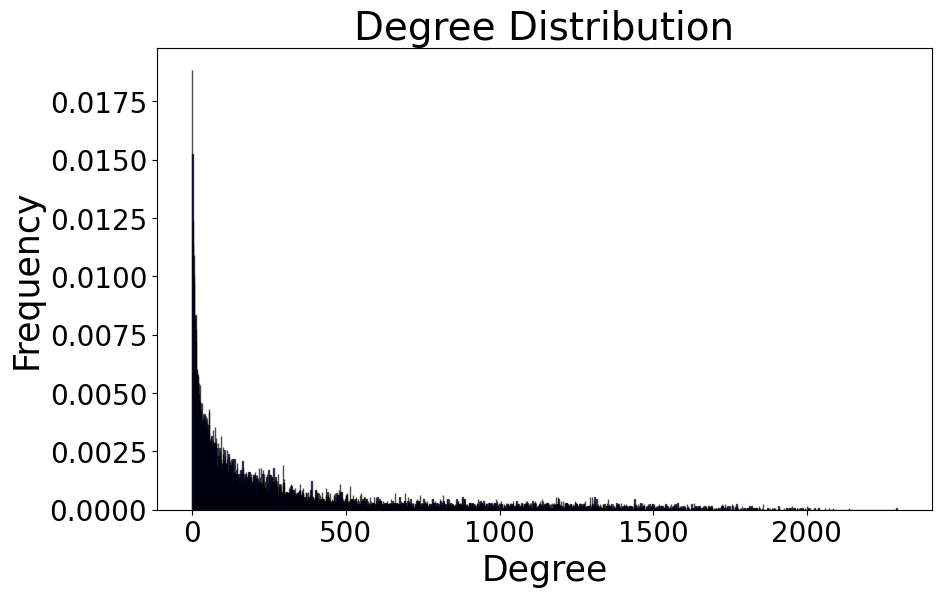

All Pairs Distances:
<class 'list'>
12939X12939


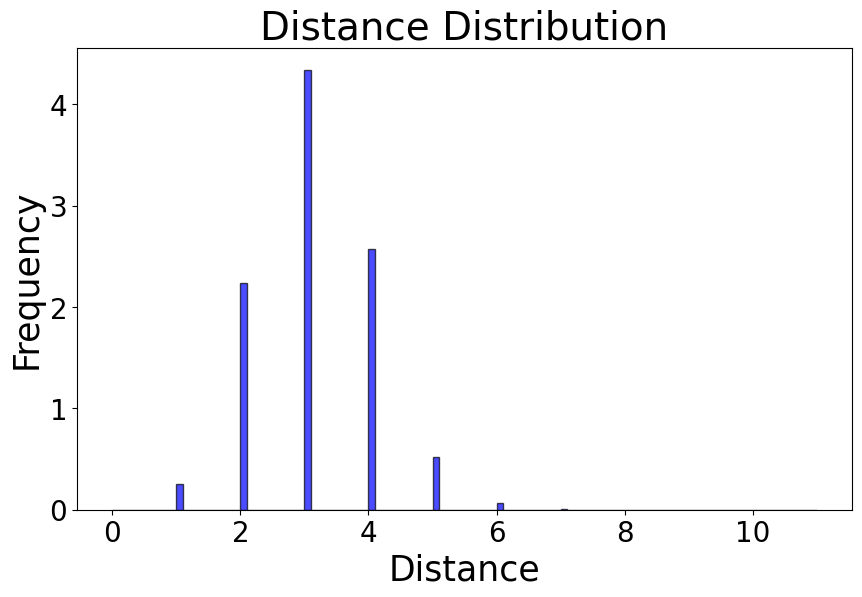

Number of vertices in largest connected component: 12677
Number of edges in largest connected component: 2022053


Symbol,TSPAN6,DPM1,SCYL3,C1orf112,FGR,FUCA2,GCLC,NFYA,STPG1,LAS1L,...,SEPSECS-AS1,LINC01144,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,0.0,3.0,3.0,3.0,4.0,3.0,3.0,3.0,4.0,3.0,...,3.0,2.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,1.0
DPM1,3.0,0.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,...,3.0,4.0,3.0,4.0,3.0,3.0,3.0,5.0,3.0,3.0
SCYL3,3.0,3.0,0.0,2.0,3.0,2.0,2.0,2.0,3.0,2.0,...,2.0,3.0,4.0,3.0,2.0,2.0,2.0,4.0,3.0,2.0
C1orf112,3.0,3.0,2.0,0.0,4.0,3.0,2.0,2.0,3.0,1.0,...,2.0,3.0,4.0,3.0,2.0,2.0,2.0,4.0,2.0,3.0
FGR,4.0,3.0,3.0,4.0,0.0,4.0,3.0,3.0,4.0,4.0,...,3.0,3.0,2.0,2.0,2.0,4.0,3.0,5.0,3.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,3.0,3.0,2.0,2.0,4.0,2.0,3.0,2.0,4.0,1.0,...,3.0,3.0,3.0,3.0,3.0,0.0,2.0,4.0,1.0,2.0
CYB561D2,3.0,3.0,2.0,2.0,3.0,2.0,2.0,2.0,3.0,1.0,...,2.0,3.0,4.0,3.0,2.0,2.0,0.0,4.0,1.0,2.0
CCDC7,3.0,5.0,4.0,4.0,5.0,4.0,4.0,4.0,4.0,4.0,...,4.0,3.0,4.0,5.0,4.0,4.0,4.0,0.0,4.0,3.0


In [10]:
distance_IV = Binary_SWITCH_pcc_to_distance(pcc_matrix=pcc_IV, fig_path1="./figures/degree_distribution_IV.svg", fig_path2="./figures/distance_distribution_IV.svg", pcc_threshold=0.7)
distance_IV.to_csv("distance_IV.csv")
distance_IV